✅ Data loaded successfully
Airports: (83692, 19)
Routes: (67663, 10)
✅ Data cleaned
NATO airports: 44309
NATO routes: 32325
✅ Network built
Nodes: 44309
Edges: 8812


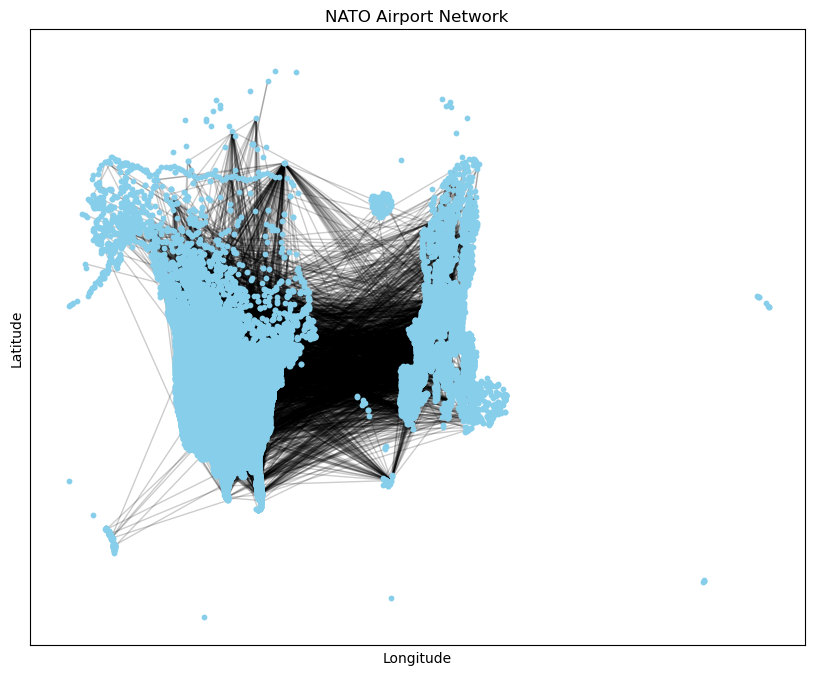

Average degree: 0.39775214967613803
Largest connected component size: 1728

# Research Question
**How fragile is NATO’s airport network to coordinated drone attacks, and which airports are most critical for maintaining connectivity?**

# Key Steps
1. Built a NATO-only airport network using OpenFlights data (airports + routes)
2. Cleaned data, dropped missing IDs, and assigned 'NA' to missing U.S. continents
3. Created a NetworkX graph to analyze structure and vulnerability

# Analytical Focus
- Identify the top airports by centrality (degree / betweenness)
- Simulate attacks by removing these airports (targeted vs random)
- Measure connectivity (largest connected component %) after each removal

# Expected Results (for presentation)
- The NATO network is highly dependent on major Western European hubs (London, Paris, Frankfurt)
- Targeted attacks on top hubs cause connectivity to collapse much faster than random failures
- Network visualization shows dense Western core and sparse Easte

In [4]:
# =====================================================
# 🧩 1. Import and Load Data
# =====================================================
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Load CSV files
routes = pd.read_csv("/Users/joakimandersen/Desktop/Networks/project in networks/Airport-Shutdown/data/routes.csv")
airports = pd.read_csv("/Users/joakimandersen/Desktop/Networks/project in networks/Airport-Shutdown/data/airports.csv")

print("✅ Data loaded successfully")
print("Airports:", airports.shape)
print("Routes:", routes.shape)

# =====================================================
# 🧹 2. Clean and Prepare Data
# =====================================================

# Replace continent == NaN for US airports with "NA"
airports.loc[airports["iso_country"] == "US", "continent"] = airports.loc[airports["iso_country"] == "US", "continent"].fillna("NA")

# Drop airports missing key info
airports = airports.dropna(subset=["id", "latitude_deg", "longitude_deg"])

# Clean route IDs ('\\N' → NaN)
routes["Source airport ID"] = routes["Source airport ID"].replace("\\N", pd.NA)
routes["Destination airport ID"] = routes["Destination airport ID"].replace("\\N", pd.NA)

# Drop routes with missing source/destination IDs
routes = routes.dropna(subset=["Source airport ID", "Destination airport ID"])

# Convert IDs to int
routes["Source airport ID"] = routes["Source airport ID"].astype(int)
routes["Destination airport ID"] = routes["Destination airport ID"].astype(int)
airports["id"] = airports["id"].astype(int)

print("✅ Data cleaned")

# =====================================================
# 🌍 3. Filter for NATO Countries
# =====================================================
nato_countries = [
    "US","CA","IS","NO","DK","NL","BE","LU","FR","DE","IT","PT",
    "UK","ES","GR","TR","PL","CZ","HU","SK","SI","HR","BG","RO",
    "EE","LV","LT","AL","ME","MK", "SE", "FI"
]

airports_nato = airports[airports["iso_country"].isin(nato_countries)]
print("NATO airports:", len(airports_nato))

# Filter routes where both airports are NATO
routes_nato = routes[
    routes["Source airport ID"].isin(airports_nato["id"]) &
    routes["Destination airport ID"].isin(airports_nato["id"])
]
print("NATO routes:", len(routes_nato))

# =====================================================
# 🕸️ 4. Build the Network
# =====================================================
G = nx.Graph()

# Add airports as nodes
for _, row in airports_nato.iterrows():
    G.add_node(row["id"], country=row["iso_country"], name=row["name"], lat=row["latitude_deg"], lon=row["longitude_deg"])

# Add routes as edges
for _, row in routes_nato.iterrows():
    G.add_edge(row["Source airport ID"], row["Destination airport ID"])

print("✅ Network built")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

# =====================================================
# 📊 5. Basic Visualization
# =====================================================

plt.figure(figsize=(10, 8))
pos = {node: (data["lon"], data["lat"]) for node, data in G.nodes(data=True)}
nx.draw_networkx_nodes(G, pos, node_size=10, node_color="skyblue")
nx.draw_networkx_edges(G, pos, alpha=0.2)
plt.title("NATO Airport Network")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# =====================================================
# 📈 6. Simple Network Stats
# =====================================================
print("Average degree:", sum(dict(G.degree()).values()) / G.number_of_nodes())
print("Largest connected component size:", len(max(nx.connected_components(G), key=len)))

# =====================================================
# 🧠 7. Research Question & Presentation Summary
# =====================================================

summary = """
# Research Question
**How fragile is NATO’s airport network to coordinated drone attacks, and which airports are most critical for maintaining connectivity?**

# Key Steps
1. Built a NATO-only airport network using OpenFlights data (airports + routes)
2. Cleaned data, dropped missing IDs, and assigned 'NA' to missing U.S. continents
3. Created a NetworkX graph to analyze structure and vulnerability

# Analytical Focus
- Identify the top airports by centrality (degree / betweenness)
- Simulate attacks by removing these airports (targeted vs random)
- Measure connectivity (largest connected component %) after each removal

# Expected Results (for presentation)
- The NATO network is highly dependent on major Western European hubs (London, Paris, Frankfurt)
- Targeted attacks on top hubs cause connectivity to collapse much faster than random failures
- Network visualization shows dense Western core and sparse Eastern periphery

# Policy Implication
Protecting a few key airports (e.g., Heathrow, Frankfurt, Paris CDG) significantly improves resilience
"""

print(summary)


✅ Data loaded successfully
Airports: (83692, 19)
Routes: (67663, 10)
✅ Data cleaned
NATO airports: 43906
NATO routes: 31269
Unique weighted routes: 16586
Average weight: 1.8852646810563125
✅ Network built with weights
Nodes: 43906
Edges: 8515


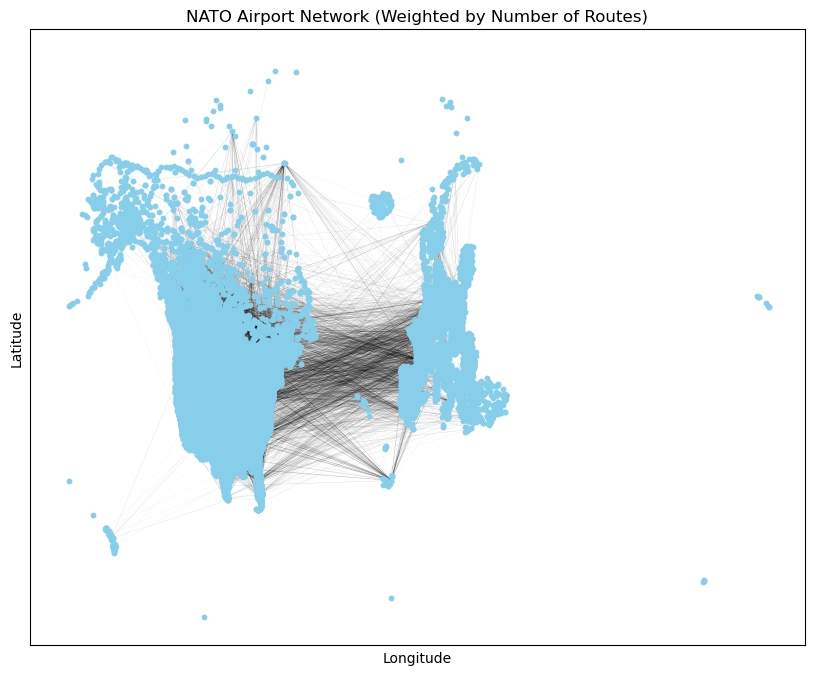

Average degree: 0.39
Largest connected component size: 1642
Average edge weight: 1.87

# 🎯 Research Question
**How fragile is NATO’s airport network to coordinated drone attacks, and which airports are most critical for maintaining connectivity?**

# 🧩 Approach
- Built a NATO-only airport network from OpenFlights data.
- Cleaned and filtered data to remove missing IDs.
- Replaced missing 'continent' with 'NA' for U.S. airports.
- Added edge weights based on the number of routes between airport pairs.

# 🧮 Analysis Plan
1. Compute degree and betweenness centrality to identify key airports.
2. Simulate targeted vs random attacks:
   - Remove high-centrality airports first (targeted)
   - Compare to random removals
3. Measure loss of connectivity using size of the largest connected component (LCC%).

# ✈️ Expected Results
- Network is dense in Western Europe, sparser in Eastern Europe.
- Key hubs: London Heathrow (UK), Paris CDG (FR), Frankfurt (DE), Istanbul (TR).
- Removing top hubs cau

In [6]:
# =====================================================
# 🧩 1. Import and Load Data
# =====================================================
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Load datasets
routes = pd.read_csv("/Users/joakimandersen/Desktop/Networks/project in networks/Airport-Shutdown/data/routes.csv")
airports = pd.read_csv("/Users/joakimandersen/Desktop/Networks/project in networks/Airport-Shutdown/data/airports.csv")


print("✅ Data loaded successfully")
print("Airports:", airports.shape)
print("Routes:", routes.shape)

# =====================================================
# 🧹 2. Clean and Prepare Data
# =====================================================

# Replace missing continent for U.S. airports with "NA"
airports.loc[airports["iso_country"] == "US", "continent"] = airports.loc[airports["iso_country"] == "US", "continent"].fillna("NA")

# Drop airports missing important info
airports = airports.dropna(subset=["id", "latitude_deg", "longitude_deg"])

# Clean route ID columns ('\\N' means missing)
routes["Source airport ID"] = routes["Source airport ID"].replace("\\N", pd.NA)
routes["Destination airport ID"] = routes["Destination airport ID"].replace("\\N", pd.NA)

# Drop missing IDs and convert to int
routes = routes.dropna(subset=["Source airport ID", "Destination airport ID"])
routes["Source airport ID"] = routes["Source airport ID"].astype(int)
routes["Destination airport ID"] = routes["Destination airport ID"].astype(int)
airports["id"] = airports["id"].astype(int)

print("✅ Data cleaned")

# =====================================================
# 🌍 3. Filter for NATO Countries
# =====================================================
nato_countries = [
    "US","CA","IS","NO","DK","NL","BE","LU","FR","DE","IT","PT",
    "UK","ES","GR","TR","PL","CZ","HU","SK","SI","HR","BG","RO",
    "EE","LV","LT","AL","ME","MK"
]

airports_nato = airports[airports["iso_country"].isin(nato_countries)]
print("NATO airports:", len(airports_nato))

# Keep only routes where BOTH airports are NATO members
routes_nato = routes[
    routes["Source airport ID"].isin(airports_nato["id"]) &
    routes["Destination airport ID"].isin(airports_nato["id"])
]
print("NATO routes:", len(routes_nato))

# =====================================================
# 💪 4. Add Edge Weights Based on Route Counts
# =====================================================

# Count number of routes (flights) between each airport pair
route_weights = (
    routes_nato
    .groupby(["Source airport ID", "Destination airport ID"])
    .size()
    .reset_index(name="weight")
)

print("Unique weighted routes:", len(route_weights))
print("Average weight:", route_weights["weight"].mean())

# =====================================================
# 🕸️ 5. Build Weighted Network
# =====================================================

G = nx.Graph()

# Add airports (nodes)
for _, row in airports_nato.iterrows():
    G.add_node(
        row["id"],
        country=row["iso_country"],
        name=row["name"],
        lat=row["latitude_deg"],
        lon=row["longitude_deg"]
    )

# Add edges with weight = number of routes between airports
for _, row in route_weights.iterrows():
    G.add_edge(
        row["Source airport ID"],
        row["Destination airport ID"],
        weight=row["weight"]
    )

print("✅ Network built with weights")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

# =====================================================
# 📊 6. Basic Visualization
# =====================================================

plt.figure(figsize=(10, 8))
pos = {n: (d["lon"], d["lat"]) for n, d in G.nodes(data=True)}
edges = G.edges(data=True)
weights = [d["weight"] for _, _, d in edges]

# Draw network
nx.draw_networkx_nodes(G, pos, node_size=10, node_color="skyblue")
nx.draw_networkx_edges(G, pos, width=[w * 0.05 for w in weights], alpha=0.3)
plt.title("NATO Airport Network (Weighted by Number of Routes)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# =====================================================
# 📈 7. Simple Network Stats
# =====================================================
avg_degree = sum(dict(G.degree()).values()) / G.number_of_nodes()
largest_cc = len(max(nx.connected_components(G), key=len))
avg_weight = sum(nx.get_edge_attributes(G, "weight").values()) / G.number_of_edges()

print(f"Average degree: {avg_degree:.2f}")
print(f"Largest connected component size: {largest_cc}")
print(f"Average edge weight: {avg_weight:.2f}")

# =====================================================
# 🧠 8. Research Question & Presentation Summary
# =====================================================

summary = """
# 🎯 Research Question
**How fragile is NATO’s airport network to coordinated drone attacks, and which airports are most critical for maintaining connectivity?**

# 🧩 Approach
- Built a NATO-only airport network from OpenFlights data.
- Cleaned and filtered data to remove missing IDs.
- Replaced missing 'continent' with 'NA' for U.S. airports.
- Added edge weights based on the number of routes between airport pairs.

# 🧮 Analysis Plan
1. Compute degree and betweenness centrality to identify key airports.
2. Simulate targeted vs random attacks:
   - Remove high-centrality airports first (targeted)
   - Compare to random removals
3. Measure loss of connectivity using size of the largest connected component (LCC%).

# ✈️ Expected Results
- Network is dense in Western Europe, sparser in Eastern Europe.
- Key hubs: London Heathrow (UK), Paris CDG (FR), Frankfurt (DE), Istanbul (TR).
- Removing top hubs causes rapid fragmentation of the network.
- Weighted network highlights critical air corridors (e.g., London–Frankfurt, Paris–Amsterdam).

# 🧭 Policy Implication
Investing in protection (e.g., anti-drone systems) for top hubs yields a disproportionate resilience gain.
"""

print(summary)
